# TP Module 1 — Premiers pas avec PyTorch

**Formation avancée en Deep Learning avec PyTorch — Computer Vision & Séries temporelles**

*Bassem Ben Hamed — ENETCOM, Université de Sfax*

---

## Objectifs du TP

À l'issue de ce TP, vous serez capable de :

1. **Créer et manipuler des tenseurs** PyTorch (création, indexation, broadcasting, reshape)
2. **Interopérer avec NumPy** et transférer des tenseurs entre CPU et GPU
3. **Utiliser `autograd`** pour calculer automatiquement les gradients
4. **Construire un modèle** en héritant de `nn.Module`
5. **Définir un `Dataset` et un `DataLoader`** personnalisés
6. **Implémenter une boucle d'entraînement complète** (train / validation / test)
7. **Sauvegarder et recharger** un modèle via `state_dict`

## Pré-requis

- Python 3.10+
- `torch`, `torchvision`, `numpy`, `matplotlib` (installés via `pip install torch torchvision numpy matplotlib`)

## Plan du notebook

1. Vérification de l'installation
2. Tenseurs : création, types, formes
3. Opérations sur tenseurs (broadcasting, reshape, view, squeeze, stack)
4. Interopérabilité avec NumPy
5. Device : CPU vs GPU (`torch.device`)
6. Autograd : différentiation automatique
7. Premier modèle from scratch (régression linéaire)
8. `nn.Module` et `nn.Sequential`
9. `Dataset` et `DataLoader` personnalisés
10. Boucle d'entraînement complète (train / val / test)
11. Sauvegarde et chargement du modèle (`state_dict`)
12. Exercices d'application

## 1. Vérification de l'installation

Avant tout, on s'assure que PyTorch est correctement installé et on récupère les informations sur l'environnement (version, support CUDA, GPU détecté).

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version       : {torch.__version__}")
print(f"NumPy version         : {np.__version__}")
print(f"CUDA disponible       : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU détecté           : {torch.cuda.get_device_name(0)}")
    print(f"Nombre de GPU         : {torch.cuda.device_count()}")
else:
    print("Aucun GPU détecté — l'exécution se fera sur CPU (acceptable pour ce TP).")

# Reproductibilité : on fixe une graine pour les générateurs aléatoires
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

PyTorch version       : 2.10.0
NumPy version         : 1.26.4
CUDA disponible       : False
Aucun GPU détecté — l'exécution se fera sur CPU (acceptable pour ce TP).


## 2. Tenseurs : création, types, formes

Un **tenseur** PyTorch est une généralisation d'une matrice à un nombre arbitraire de dimensions. C'est la structure de données centrale du framework : tous les inputs, paramètres, activations et gradients sont des tenseurs.

**Attributs essentiels d'un tenseur :**
- `.shape` ou `.size()` — forme (tuple de dimensions)
- `.dtype` — type des éléments (`torch.float32`, `torch.int64`, ...)
- `.device` — emplacement physique (`cpu` ou `cuda:0`)
- `.requires_grad` — si True, autograd suit les opérations pour la rétropropagation

In [2]:
# --- Création directe depuis des données Python ---
t0 = torch.tensor(3.14)                       # scalaire (0-D)
t1 = torch.tensor([1.0, 2.0, 3.0])             # vecteur (1-D)
t2 = torch.tensor([[1, 2, 3], [4, 5, 6]])      # matrice (2-D)

print("t0 :", t0, "| shape :", t0.shape, "| dtype :", t0.dtype)
print("t1 :", t1, "| shape :", t1.shape, "| dtype :", t1.dtype)
print("t2 :\n", t2, "\nshape :", t2.shape, "| dtype :", t2.dtype)

t0 : tensor(3.1400) | shape : torch.Size([]) | dtype : torch.float32
t1 : tensor([1., 2., 3.]) | shape : torch.Size([3]) | dtype : torch.float32
t2 :
 tensor([[1, 2, 3],
        [4, 5, 6]]) 
shape : torch.Size([2, 3]) | dtype : torch.int64


In [3]:
# --- Constructeurs usuels ---
zeros  = torch.zeros(2, 3)                    # tenseur de zéros (float32)
ones   = torch.ones(2, 3, dtype=torch.int32)  # avec un dtype explicite
rand_u = torch.rand(2, 3)                     # loi uniforme [0, 1)
rand_n = torch.randn(2, 3)                    # loi normale N(0, 1)
iden   = torch.eye(3)                         # matrice identité 3x3
arng   = torch.arange(0, 10, 2)               # [0, 2, 4, 6, 8]
lins   = torch.linspace(0, 1, steps=5)        # 5 valeurs équiréparties dans [0, 1]

print("zeros :\n", zeros)
print("ones (int32) :\n", ones)
print("rand uniforme :\n", rand_u)
print("randn normale :\n", rand_n)
print("identité :\n", iden)
print("arange  :", arng)
print("linspace:", lins)

zeros :
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
ones (int32) :
 tensor([[1, 1, 1],
        [1, 1, 1]], dtype=torch.int32)
rand uniforme :
 tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009]])
randn normale :
 tensor([[ 1.1561,  0.3965, -2.4661],
        [ 0.3623,  0.3765, -0.1808]])
identité :
 tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])
arange  : tensor([0, 2, 4, 6, 8])
linspace: tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


In [4]:
# --- *_like : créer un tenseur de même forme qu'un autre ---
ref = torch.randn(3, 4)
z   = torch.zeros_like(ref)   # même shape, même dtype, même device
o   = torch.ones_like(ref)
r   = torch.randn_like(ref)

print("ref.shape :", ref.shape)
print("z.shape   :", z.shape, "| dtype :", z.dtype)
print("o.shape   :", o.shape)
print("r.shape   :", r.shape)

ref.shape : torch.Size([3, 4])
z.shape   : torch.Size([3, 4]) | dtype : torch.float32
o.shape   : torch.Size([3, 4])
r.shape   : torch.Size([3, 4])


### Conversion de type (`dtype`)

Le dtype par défaut des flottants est `torch.float32`, des entiers `torch.int64`. On peut convertir explicitement avec `.to(dtype)`, `.float()`, `.long()`, etc.

**Bon réflexe** : les inputs/poids des réseaux sont en `float32`, les labels de classification en `int64` (`long`).

In [5]:
x = torch.tensor([1, 2, 3])             # par défaut int64
print("x dtype :", x.dtype)

x_float = x.float()                      # -> torch.float32
x_dbl   = x.to(torch.float64)            # -> torch.float64
x_long  = x_float.long()                 # -> torch.int64

print("x_float dtype :", x_float.dtype)
print("x_dbl   dtype :", x_dbl.dtype)
print("x_long  dtype :", x_long.dtype)

x dtype : torch.int64
x_float dtype : torch.float32
x_dbl   dtype : torch.float64
x_long  dtype : torch.int64


## 3. Opérations sur tenseurs

### 3.1 Arithmétique et indexation

Les opérations classiques (+, -, *, /, @, **) fonctionnent élément par élément, sauf `@` qui est le produit matriciel. L'indexation suit la convention NumPy.

In [6]:
a = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
b = torch.tensor([[5.0, 6.0], [7.0, 8.0]])

print("a + b :\n", a + b)
print("a * b (élément par élément) :\n", a * b)
print("a @ b (produit matriciel) :\n", a @ b)
print("a.T (transposée) :\n", a.T)

# Indexation
print("\na[0]      :", a[0])      # première ligne
print("a[:, 1]   :", a[:, 1])     # deuxième colonne
print("a[0, 1]   :", a[0, 1])     # élément (0, 1)

# Réductions
print("\na.sum()      :", a.sum())
print("a.mean()     :", a.mean())
print("a.max()      :", a.max())
print("a.sum(dim=0) :", a.sum(dim=0))   # somme par colonne
print("a.sum(dim=1) :", a.sum(dim=1))   # somme par ligne

a + b :
 tensor([[ 6.,  8.],
        [10., 12.]])
a * b (élément par élément) :
 tensor([[ 5., 12.],
        [21., 32.]])
a @ b (produit matriciel) :
 tensor([[19., 22.],
        [43., 50.]])
a.T (transposée) :
 tensor([[1., 3.],
        [2., 4.]])

a[0]      : tensor([1., 2.])
a[:, 1]   : tensor([2., 4.])
a[0, 1]   : tensor(2.)

a.sum()      : tensor(10.)
a.mean()     : tensor(2.5000)
a.max()      : tensor(4.)
a.sum(dim=0) : tensor([4., 6.])
a.sum(dim=1) : tensor([3., 7.])


### 3.2 Broadcasting

Le **broadcasting** étend automatiquement deux tenseurs de formes compatibles pour permettre l'opération sans copie de mémoire.

**Règles :**
1. Aligner les shapes à droite.
2. Chaque dimension doit être égale, ou l'une des deux doit valoir 1.
3. Les dimensions de taille 1 sont "répétées" virtuellement.

In [7]:
# Exemple 1 : ajouter un vecteur à chaque ligne d'une matrice
M = torch.zeros(3, 4)                  # shape (3, 4)
v = torch.tensor([1.0, 2.0, 3.0, 4.0]) # shape (4,)  -> broadcast en (1, 4) puis (3, 4)
print("M + v :\n", M + v)

# Exemple 2 : centrer chaque ligne (soustraire sa moyenne)
X = torch.randn(5, 3)
row_mean = X.mean(dim=1, keepdim=True)   # shape (5, 1)
X_centered = X - row_mean                 # broadcast (5, 1) -> (5, 3)
print("\nMoyennes par ligne (avant) :", X.mean(dim=1))
print("Moyennes par ligne (après) :", X_centered.mean(dim=1))

M + v :
 tensor([[1., 2., 3., 4.],
        [1., 2., 3., 4.],
        [1., 2., 3., 4.]])

Moyennes par ligne (avant) : tensor([-0.2999, -0.0347, -0.1344,  0.9352,  0.3136])
Moyennes par ligne (après) : tensor([-3.9736e-08, -9.9341e-09,  3.9736e-08,  3.9736e-08,  0.0000e+00])


### 3.3 Reshape, view, squeeze, unsqueeze, stack, cat

Ces opérations changent la **forme** d'un tenseur sans modifier ses données (sauf `cat` et `stack` qui assemblent plusieurs tenseurs).

| Opération | Effet |
|-----------|-------|
| `view(shape)` | nouvelle forme, mémoire contiguë requise |
| `reshape(shape)` | idem, copie si nécessaire (plus permissif) |
| `squeeze(dim?)` | supprime les dimensions de taille 1 |
| `unsqueeze(dim)` | ajoute une dimension de taille 1 |
| `cat([t1, t2], dim=k)` | concatène le long d'une dimension existante |
| `stack([t1, t2], dim=k)` | empile en créant une nouvelle dimension |
| `permute(dims)` | réordonne les axes |

In [8]:
x = torch.arange(12)              # shape (12,)
print("x         :", x.shape)

x34 = x.view(3, 4)                # shape (3, 4) — partage la mémoire de x
print("x.view(3,4):", x34.shape)

x_43 = x.reshape(4, 3)            # shape (4, 3)
print("x.reshape(4,3):", x_43.shape)

# Ajout/suppression de dimensions
y = torch.zeros(1, 3, 1, 5)
print("\ny.shape           :", y.shape)
print("y.squeeze().shape :", y.squeeze().shape)         # (3, 5)
print("y.squeeze(0).shape:", y.squeeze(0).shape)        # (3, 1, 5) -- ne touche que dim 0

z = torch.zeros(3, 5)
print("\nz.unsqueeze(0).shape :", z.unsqueeze(0).shape)  # (1, 3, 5) -- ajoute une dim batch
print("z.unsqueeze(1).shape :", z.unsqueeze(1).shape)    # (3, 1, 5)

x         : torch.Size([12])
x.view(3,4): torch.Size([3, 4])
x.reshape(4,3): torch.Size([4, 3])

y.shape           : torch.Size([1, 3, 1, 5])
y.squeeze().shape : torch.Size([3, 5])
y.squeeze(0).shape: torch.Size([3, 1, 5])

z.unsqueeze(0).shape : torch.Size([1, 3, 5])
z.unsqueeze(1).shape : torch.Size([3, 1, 5])


In [9]:
# Concaténation vs empilement
a = torch.tensor([[1, 2], [3, 4]])
b = torch.tensor([[5, 6], [7, 8]])

cat0 = torch.cat([a, b], dim=0)   # (4, 2) — concatène le long de l'axe 0
cat1 = torch.cat([a, b], dim=1)   # (2, 4) — concatène le long de l'axe 1
stk  = torch.stack([a, b], dim=0) # (2, 2, 2) — nouvelle dim au début

print("cat dim=0 :\n", cat0, cat0.shape)
print("cat dim=1 :\n", cat1, cat1.shape)
print("stack     :\n", stk,  stk.shape)

# permute : utile pour passer d'une convention NHWC (TF) à NCHW (PyTorch)
img_nhwc = torch.randn(8, 32, 32, 3)            # batch=8, H=32, W=32, C=3
img_nchw = img_nhwc.permute(0, 3, 1, 2)         # -> (8, 3, 32, 32)
print("\nNHWC :", img_nhwc.shape, "-> NCHW :", img_nchw.shape)

cat dim=0 :
 tensor([[1, 2],
        [3, 4],
        [5, 6],
        [7, 8]]) torch.Size([4, 2])
cat dim=1 :
 tensor([[1, 2, 5, 6],
        [3, 4, 7, 8]]) torch.Size([2, 4])
stack     :
 tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]]) torch.Size([2, 2, 2])

NHWC : torch.Size([8, 32, 32, 3]) -> NCHW : torch.Size([8, 3, 32, 32])


## 4. Interopérabilité avec NumPy

Conversion **sans copie** entre `torch.Tensor` et `np.ndarray` (sur CPU uniquement). Pratique pour réutiliser du code NumPy ou pour la visualisation.

**Attention** : la mémoire est partagée. Modifier l'un modifie l'autre.

In [10]:
# NumPy -> Tensor
arr  = np.array([[1.0, 2.0], [3.0, 4.0]])
t_np = torch.from_numpy(arr)
print("tensor depuis numpy :\n", t_np, "| dtype :", t_np.dtype)

# Tensor -> NumPy
t   = torch.linspace(0, 1, 5)
arr = t.numpy()
print("\nnumpy depuis tensor :", arr, type(arr))

# Démonstration du partage de mémoire
t[0] = 99.0
print("après t[0] = 99 :")
print("  tensor :", t)
print("  numpy  :", arr, " <-- modifié aussi !")

tensor depuis numpy :
 tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64) | dtype : torch.float64

numpy depuis tensor : [0.   0.25 0.5  0.75 1.  ] <class 'numpy.ndarray'>
après t[0] = 99 :
  tensor : tensor([99.0000,  0.2500,  0.5000,  0.7500,  1.0000])
  numpy  : [99.    0.25  0.5   0.75  1.  ]  <-- modifié aussi !


## 5. Device : CPU vs GPU

PyTorch supporte le calcul sur GPU via CUDA. Un tenseur doit être **explicitement** placé sur un device (`cpu` ou `cuda:0`). Les opérations entre tenseurs nécessitent qu'ils soient sur le même device.

**Convention :**
```python
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tensor = tensor.to(device)
model  = model.to(device)
```

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

# Création directement sur le device
x_gpu = torch.randn(3, 3, device=device)
print("x_gpu.device :", x_gpu.device)

# Transfert d'un tenseur CPU vers le device
x_cpu = torch.randn(3, 3)
x_cpu_to_dev = x_cpu.to(device)
print("x_cpu.device        :", x_cpu.device)
print("x_cpu_to_dev.device :", x_cpu_to_dev.device)

# Retour vers le CPU (obligatoire avant un .numpy() ou un plt.imshow())
back_to_cpu = x_gpu.cpu()
print("back_to_cpu.device  :", back_to_cpu.device)

Device utilisé : cpu
x_gpu.device : cpu
x_cpu.device        : cpu
x_cpu_to_dev.device : cpu
back_to_cpu.device  : cpu


## 6. Autograd : différentiation automatique

PyTorch construit dynamiquement un **graphe de calcul** : chaque opération sur des tenseurs avec `requires_grad=True` enregistre une fonction de gradient. L'appel à `.backward()` parcourt ce graphe en sens inverse pour calculer les gradients par rapport aux feuilles.

### 6.1 Exemple simple : dérivée d'une fonction scalaire

Soit $f(x) = 3x^2 + 2x + 1$. Sa dérivée est $f'(x) = 6x + 2$. Pour $x = 4$, on attend $f'(4) = 26$.

In [12]:
x = torch.tensor(4.0, requires_grad=True)
y = 3 * x**2 + 2 * x + 1
y.backward()                  # calcule dy/dx et le stocke dans x.grad

print(f"y       = {y.item()}")     # 3*16 + 2*4 + 1 = 57
print(f"dy/dx   = {x.grad.item()}")  # 6*4 + 2 = 26

y       = 57.0
dy/dx   = 26.0


### 6.2 Gradient d'une fonction vectorielle (loss)

Dans un réseau, on calcule typiquement une **loss scalaire** (somme ou moyenne sur le batch) et on rétropropage.

In [13]:
# Régression linéaire scalaire : on cherche w tel que w*x ≈ y
x = torch.tensor([1.0, 2.0, 3.0, 4.0])
y = torch.tensor([2.0, 4.0, 6.0, 8.0])     # y = 2*x exactement

w = torch.tensor(0.0, requires_grad=True)  # paramètre à apprendre

y_pred = w * x
loss   = ((y_pred - y) ** 2).mean()        # MSE
loss.backward()

print(f"loss     = {loss.item():.4f}")
print(f"dL/dw    = {w.grad.item():.4f}")
# Vérification analytique : dL/dw = (2/N) * sum((w*x - y)*x) = (2/4) * (-30) = -15

loss     = 30.0000
dL/dw    = -30.0000


### 6.3 Pièges à éviter

- **Les gradients s'accumulent.** Toujours appeler `optimizer.zero_grad()` (ou `tensor.grad.zero_()`) avant chaque `backward()`.
- **`requires_grad=True` propage.** Toute opération sur un tenseur "feuille" produit un tenseur dans le graphe.
- **`with torch.no_grad():`** désactive temporairement le suivi des gradients (utile pour l'inférence ou la validation).
- **`.detach()`** crée une vue sans gradient (utile pour les statistiques, le logging, etc.).

In [14]:
# Démonstration de l'accumulation des gradients
w = torch.tensor(1.0, requires_grad=True)
for step in range(3):
    loss = (w * 2) ** 2          # L = 4*w^2 ; dL/dw = 8*w
    loss.backward()
    print(f"étape {step} | w.grad (cumulé) = {w.grad.item()}")

# On réinitialise et on recommence proprement
print("\n--- Avec zero_grad() entre chaque étape ---")
w = torch.tensor(1.0, requires_grad=True)
for step in range(3):
    if w.grad is not None:
        w.grad.zero_()
    loss = (w * 2) ** 2
    loss.backward()
    print(f"étape {step} | w.grad = {w.grad.item()}")

étape 0 | w.grad (cumulé) = 8.0
étape 1 | w.grad (cumulé) = 16.0
étape 2 | w.grad (cumulé) = 24.0

--- Avec zero_grad() entre chaque étape ---
étape 0 | w.grad = 8.0
étape 1 | w.grad = 8.0
étape 2 | w.grad = 8.0


In [15]:
# torch.no_grad() et .detach()
w = torch.tensor(2.0, requires_grad=True)

with torch.no_grad():
    y = w * 3                      # y n'a pas de gradient
    print("dans no_grad — y.requires_grad :", y.requires_grad)

y2 = w * 3
print("hors no_grad — y2.requires_grad   :", y2.requires_grad)

y3 = y2.detach()
print("après detach — y3.requires_grad   :", y3.requires_grad)

dans no_grad — y.requires_grad : False
hors no_grad — y2.requires_grad   : True
après detach — y3.requires_grad   : False


## 7. Premier modèle from scratch — régression linéaire

On va apprendre la fonction $y = 3x + 2$ à partir de données bruitées, en **manuel** (sans `nn.Module`) pour bien comprendre la mécanique.

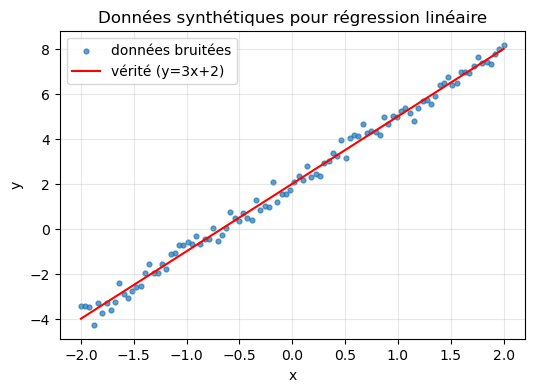

In [16]:
# Génération de données synthétiques
torch.manual_seed(SEED)
N = 100
x_data = torch.linspace(-2, 2, N).unsqueeze(1)              # shape (100, 1)
y_true = 3 * x_data + 2
y_data = y_true + 0.3 * torch.randn_like(y_true)            # bruit gaussien

plt.figure(figsize=(6, 4))
plt.scatter(x_data.numpy(), y_data.numpy(), s=12, alpha=0.7, label="données bruitées")
plt.plot(x_data.numpy(), y_true.numpy(), color="red", label="vérité (y=3x+2)")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Données synthétiques pour régression linéaire")
plt.show()

In [17]:
# Paramètres initialisés aléatoirement
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

lr = 0.05
num_epochs = 200
history = []

for epoch in range(num_epochs):
    # Forward
    y_pred = w * x_data + b
    loss   = ((y_pred - y_data) ** 2).mean()

    # Backward
    loss.backward()

    # Mise à jour manuelle des paramètres (descente de gradient)
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
        w.grad.zero_()
        b.grad.zero_()

    history.append(loss.item())
    if (epoch + 1) % 25 == 0:
        print(f"epoch {epoch+1:3d} | loss = {loss.item():.4f} | w = {w.item():.3f} | b = {b.item():.3f}")

print(f"\nValeurs apprises : w = {w.item():.3f}  (vrai 3.0), b = {b.item():.3f}  (vrai 2.0)")

epoch  25 | loss = 0.1448 | w = 2.903 | b = 1.832
epoch  50 | loss = 0.0869 | w = 2.993 | b = 2.005
epoch  75 | loss = 0.0867 | w = 2.996 | b = 2.017
epoch 100 | loss = 0.0867 | w = 2.996 | b = 2.018
epoch 125 | loss = 0.0867 | w = 2.996 | b = 2.018
epoch 150 | loss = 0.0867 | w = 2.996 | b = 2.018
epoch 175 | loss = 0.0867 | w = 2.996 | b = 2.018
epoch 200 | loss = 0.0867 | w = 2.996 | b = 2.018

Valeurs apprises : w = 2.996  (vrai 3.0), b = 2.018  (vrai 2.0)


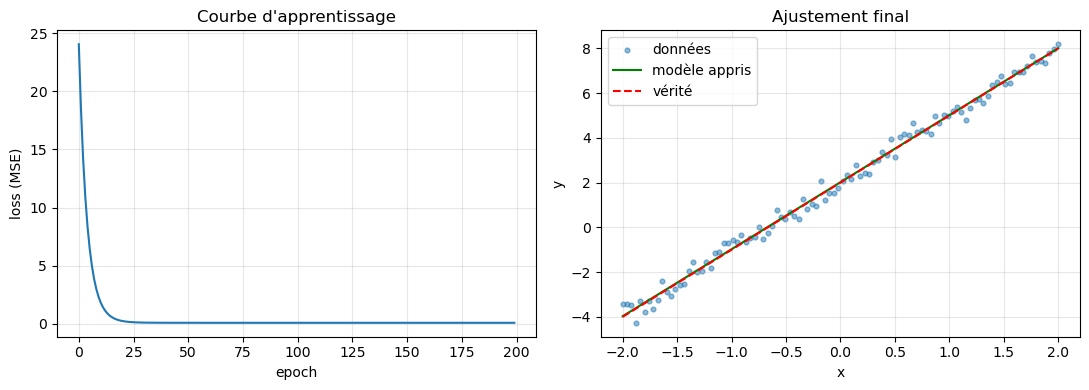

In [18]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss (MSE)")
axes[0].set_title("Courbe d'apprentissage"); axes[0].grid(alpha=0.3)

with torch.no_grad():
    y_fit = w * x_data + b
axes[1].scatter(x_data.numpy(), y_data.numpy(), s=12, alpha=0.5, label="données")
axes[1].plot(x_data.numpy(), y_fit.numpy(), color="green", label="modèle appris")
axes[1].plot(x_data.numpy(), y_true.numpy(), color="red", linestyle="--", label="vérité")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title("Ajustement final")
plt.tight_layout(); plt.show()

## 8. `nn.Module` et `nn.Sequential`

En pratique, on n'écrit jamais la descente de gradient à la main. PyTorch fournit :

- **`nn.Module`** : classe de base de tout modèle. On définit ses sous-modules dans `__init__` et la propagation avant dans `forward`.
- **`nn.Linear`, `nn.Conv2d`, ...** : couches prédéfinies, avec paramètres apprenables (`weight`, `bias`).
- **`nn.Sequential`** : conteneur pour chaîner des couches sans écrire de classe.
- **`torch.optim`** : optimiseurs (SGD, Adam, RMSprop, ...) qui automatisent la mise à jour des paramètres.
- **`nn.MSELoss`, `nn.CrossEntropyLoss`, ...** : fonctions de coût.

In [19]:
import torch.nn as nn

# --- Version 1 : nn.Sequential (concis) ---
model_seq = nn.Sequential(
    nn.Linear(in_features=1, out_features=16),
    nn.ReLU(),
    nn.Linear(in_features=16, out_features=1),
)
print("Modèle Sequential :\n", model_seq)

# --- Version 2 : classe héritant de nn.Module (plus flexible) ---
class TinyMLP(nn.Module):
    def __init__(self, in_dim=1, hidden=16, out_dim=1):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden, out_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        return x

model = TinyMLP()
print("\nModèle TinyMLP :\n", model)

# Inspection des paramètres
print("\nParamètres apprenables :")
for name, p in model.named_parameters():
    print(f"  {name:10s} | shape = {tuple(p.shape)} | requires_grad = {p.requires_grad}")

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nNombre total de paramètres : {n_params}")

Modèle Sequential :
 Sequential(
  (0): Linear(in_features=1, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
)

Modèle TinyMLP :
 TinyMLP(
  (fc1): Linear(in_features=1, out_features=16, bias=True)
  (act): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)

Paramètres apprenables :
  fc1.weight | shape = (16, 1) | requires_grad = True
  fc1.bias   | shape = (16,) | requires_grad = True
  fc2.weight | shape = (1, 16) | requires_grad = True
  fc2.bias   | shape = (1,) | requires_grad = True

Nombre total de paramètres : 49


## 9. `Dataset` et `DataLoader` personnalisés

En production, on ne charge jamais tout en mémoire d'un coup. PyTorch propose deux abstractions :

- **`torch.utils.data.Dataset`** : classe abstraite. On hérite et on implémente :
  - `__len__(self)` : nombre d'échantillons
  - `__getitem__(self, idx)` : renvoie le tuple `(x, y)` du `idx`-ième échantillon
- **`torch.utils.data.DataLoader`** : itérateur qui assemble les échantillons en batchs, mélange (`shuffle`), parallélise le chargement (`num_workers`), épingle la mémoire pour GPU (`pin_memory`).

Taille du dataset : 800
Premier échantillon : x = 0.765, y = -0.858


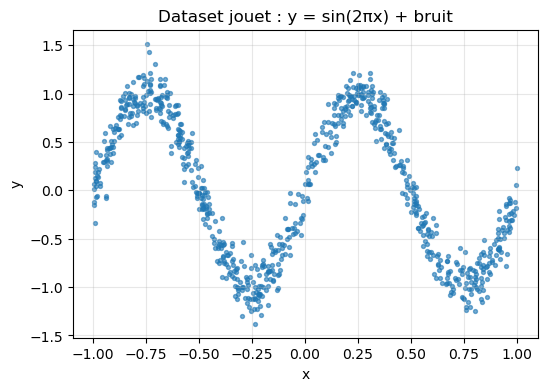

In [20]:
from torch.utils.data import Dataset, DataLoader, random_split

class SignalDataset(Dataset):
    """Dataset jouet : signaux 1D générés par une fonction inconnue + bruit.

    Chaque échantillon est (x, y) avec y = sin(2*pi*x) + bruit.
    On l'utilise comme exemple de régression non linéaire.
    """
    def __init__(self, n_samples=500, noise_std=0.1, seed=0):
        g = torch.Generator().manual_seed(seed)
        self.x = torch.rand(n_samples, 1, generator=g) * 2 - 1   # x ~ U(-1, 1)
        self.y = torch.sin(2 * torch.pi * self.x) + noise_std * torch.randn(n_samples, 1, generator=g)

    def __len__(self):
        return self.x.size(0)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

# Construction et inspection
dataset = SignalDataset(n_samples=800, noise_std=0.15, seed=SEED)
print(f"Taille du dataset : {len(dataset)}")
x0, y0 = dataset[0]
print(f"Premier échantillon : x = {x0.item():.3f}, y = {y0.item():.3f}")

# Visualisation
plt.figure(figsize=(6, 4))
plt.scatter(dataset.x.numpy(), dataset.y.numpy(), s=8, alpha=0.6)
plt.title("Dataset jouet : y = sin(2πx) + bruit")
plt.xlabel("x"); plt.ylabel("y"); plt.grid(alpha=0.3); plt.show()

In [21]:
# Split train / val / test (70 / 15 / 15)
n_total = len(dataset)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)
n_test  = n_total - n_train - n_val

train_set, val_set, test_set = random_split(
    dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)
print(f"Train : {len(train_set)} | Val : {len(val_set)} | Test : {len(test_set)}")

# DataLoaders
BATCH = 32
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=BATCH, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=BATCH, shuffle=False, num_workers=0)

# Inspection d'un batch
x_batch, y_batch = next(iter(train_loader))
print(f"\nUn batch d'entraînement : x.shape = {x_batch.shape}, y.shape = {y_batch.shape}")

Train : 560 | Val : 120 | Test : 120

Un batch d'entraînement : x.shape = torch.Size([32, 1]), y.shape = torch.Size([32, 1])


## 10. Boucle d'entraînement complète

On encapsule la logique en deux fonctions réutilisables :

- `train_one_epoch(...)` : une époque complète d'entraînement (mode `train`, mise à jour des poids).
- `evaluate(...)` : passe en mode `eval` + `torch.no_grad()` pour la validation/test.

**Pattern PyTorch canonique d'une itération d'entraînement :**
```python
optimizer.zero_grad()           # 1. réinitialiser les gradients
y_pred = model(x)               # 2. forward
loss   = criterion(y_pred, y)   # 3. coût
loss.backward()                 # 4. backward (calcule les gradients)
optimizer.step()                # 5. mise à jour des poids
```

In [22]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()                         # active dropout, batchnorm en mode train, etc.
    running_loss = 0.0
    n_seen = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        y_pred = model(x)
        loss   = criterion(y_pred, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        n_seen       += x.size(0)
    return running_loss / n_seen

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()                          # désactive dropout, BN passe en mode running stats
    running_loss = 0.0
    n_seen = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        y_pred = model(x)
        loss   = criterion(y_pred, y)
        running_loss += loss.item() * x.size(0)
        n_seen       += x.size(0)
    return running_loss / n_seen

In [23]:
# Instanciation du modèle, de la loss et de l'optimiseur
model     = TinyMLP(in_dim=1, hidden=32, out_dim=1).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

EPOCHS = 80
train_losses, val_losses = [], []
best_val = float("inf")
best_state = None

for epoch in range(1, EPOCHS + 1):
    tl = train_one_epoch(model, train_loader, criterion, optimizer, device)
    vl = evaluate(model, val_loader, criterion, device)
    train_losses.append(tl); val_losses.append(vl)

    # Early-stopping manuel : on retient le meilleur état sur la validation
    if vl < best_val:
        best_val   = vl
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0 or epoch == 1:
        print(f"epoch {epoch:3d} | train loss = {tl:.4f} | val loss = {vl:.4f}")

# On recharge le meilleur état pour évaluer sur le test
model.load_state_dict(best_state)
test_loss = evaluate(model, test_loader, criterion, device)
print(f"\nMeilleure val loss : {best_val:.4f}")
print(f"Test loss (meilleur modèle) : {test_loss:.4f}")

epoch   1 | train loss = 0.4427 | val loss = 0.4485
epoch  10 | train loss = 0.1754 | val loss = 0.1585
epoch  20 | train loss = 0.0800 | val loss = 0.0675
epoch  30 | train loss = 0.0484 | val loss = 0.0390
epoch  40 | train loss = 0.0349 | val loss = 0.0408
epoch  50 | train loss = 0.0307 | val loss = 0.0302
epoch  60 | train loss = 0.0304 | val loss = 0.0367
epoch  70 | train loss = 0.0280 | val loss = 0.0289
epoch  80 | train loss = 0.0282 | val loss = 0.0385

Meilleure val loss : 0.0274
Test loss (meilleur modèle) : 0.0216


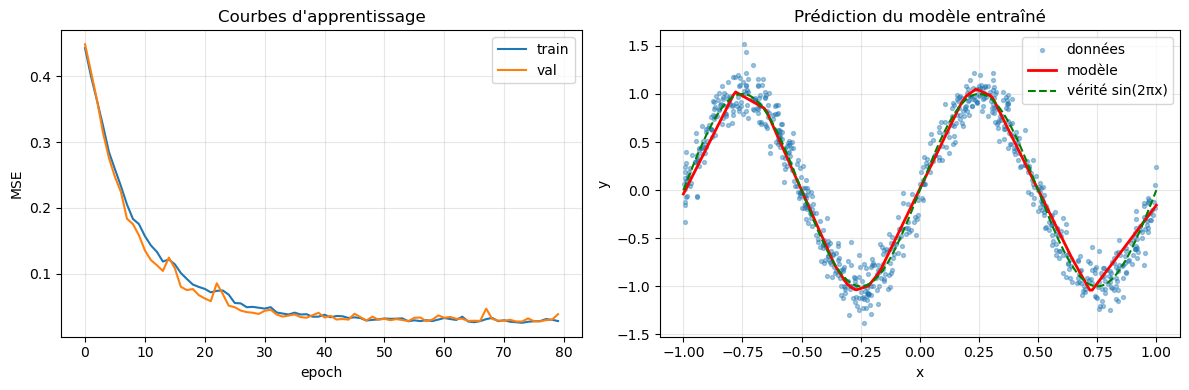

In [24]:
# Visualisation des courbes d'apprentissage et de la prédiction
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label="train")
axes[0].plot(val_losses,   label="val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MSE")
axes[0].set_title("Courbes d'apprentissage"); axes[0].legend(); axes[0].grid(alpha=0.3)

# Prédiction sur une grille dense
model.eval()
with torch.no_grad():
    x_grid = torch.linspace(-1, 1, 200).unsqueeze(1).to(device)
    y_grid = model(x_grid).cpu()

axes[1].scatter(dataset.x.numpy(), dataset.y.numpy(), s=8, alpha=0.4, label="données")
axes[1].plot(x_grid.cpu().numpy(), y_grid.numpy(), color="red", lw=2, label="modèle")
axes[1].plot(x_grid.cpu().numpy(), torch.sin(2 * torch.pi * x_grid.cpu()).numpy(),
             color="green", linestyle="--", label="vérité sin(2πx)")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title("Prédiction du modèle entraîné")
plt.tight_layout(); plt.show()

## 11. Sauvegarde et chargement du modèle

**Bonne pratique PyTorch** : sauvegarder le **`state_dict`** (dictionnaire des poids), pas l'objet modèle complet. Cela rend le checkpoint indépendant du code source et compatible avec différentes architectures.

```python
torch.save(model.state_dict(), "checkpoint.pt")     # sauvegarde

model = MyModel(...)                                # reconstruit l'architecture
model.load_state_dict(torch.load("checkpoint.pt"))  # recharge les poids
model.eval()
```

Pour un **checkpoint complet** (poids + optimiseur + époque), on sauvegarde un dict.

In [25]:
import os

ckpt_dir = "checkpoints"
os.makedirs(ckpt_dir, exist_ok=True)

# Sauvegarde minimale : seulement les poids
weights_path = os.path.join(ckpt_dir, "tinymlp_weights.pt")
torch.save(model.state_dict(), weights_path)
print(f"Poids sauvegardés dans : {weights_path}")

# Sauvegarde complète : poids + optimiseur + métadonnées
full_ckpt_path = os.path.join(ckpt_dir, "tinymlp_full.pt")
torch.save({
    "epoch":                EPOCHS,
    "model_state_dict":     model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "best_val_loss":        best_val,
    "test_loss":            test_loss,
}, full_ckpt_path)
print(f"Checkpoint complet sauvegardé dans : {full_ckpt_path}")

Poids sauvegardés dans : checkpoints/tinymlp_weights.pt
Checkpoint complet sauvegardé dans : checkpoints/tinymlp_full.pt


In [26]:
# Rechargement dans un modèle neuf
model_reloaded = TinyMLP(in_dim=1, hidden=32, out_dim=1).to(device)
model_reloaded.load_state_dict(torch.load(weights_path, map_location=device))
model_reloaded.eval()

# Vérification : on doit retrouver la même test loss
test_loss_reloaded = evaluate(model_reloaded, test_loader, criterion, device)
print(f"Test loss du modèle rechargé : {test_loss_reloaded:.4f}")
print(f"Test loss du modèle d'origine : {test_loss:.4f}")
assert abs(test_loss_reloaded - test_loss) < 1e-6, "Les pertes diffèrent — souci de chargement !"
print("OK — le modèle a bien été rechargé à l'identique.")

Test loss du modèle rechargé : 0.0216
Test loss du modèle d'origine : 0.0216
OK — le modèle a bien été rechargé à l'identique.


In [27]:
# Reprise d'entraînement à partir d'un checkpoint complet
ckpt = torch.load(full_ckpt_path, map_location=device)
print("Clés du checkpoint :", list(ckpt.keys()))
print(f"Epoque sauvegardée : {ckpt['epoch']}")
print(f"Best val loss     : {ckpt['best_val_loss']:.4f}")

# Reconstruire modèle + optimiseur, puis recharger
model_resume     = TinyMLP(in_dim=1, hidden=32, out_dim=1).to(device)
optimizer_resume = torch.optim.Adam(model_resume.parameters(), lr=1e-2)

model_resume.load_state_dict(ckpt["model_state_dict"])
optimizer_resume.load_state_dict(ckpt["optimizer_state_dict"])
start_epoch = ckpt["epoch"] + 1

print(f"\nReprise prête : on pourrait continuer à l'époque {start_epoch}.")

Clés du checkpoint : ['epoch', 'model_state_dict', 'optimizer_state_dict', 'best_val_loss', 'test_loss']
Epoque sauvegardée : 80
Best val loss     : 0.0274

Reprise prête : on pourrait continuer à l'époque 81.


## 12. Exercices d'application

Pour vous entraîner — chaque exercice prend 10 à 20 minutes.

### Exercice 1 — Manipulation de tenseurs
Créez un tenseur 3-D de forme `(4, 5, 6)` rempli de valeurs aléatoires N(0, 1). Puis :
1. Calculez la moyenne et l'écart-type globaux, puis par axe 0.
2. Normalisez le tenseur (moyenne 0, écart-type 1) par batch (axe 0).
3. Reshape vers `(4, 30)` puis `(20, 6)`.
4. Concaténez deux tels tenseurs le long de l'axe 1 puis le long d'un nouvel axe.

### Exercice 2 — Autograd manuel
Soit $f(x, y) = x^2 y + \sin(y)$. Calculez analytiquement $\partial f/\partial x$ et $\partial f/\partial y$ en $(x, y) = (2, 1)$, puis vérifiez avec PyTorch.

### Exercice 3 — Dataset custom
Implémentez un `Dataset` qui charge un fichier CSV (ex. signaux ECG) :
- Constructeur reçoit le chemin du CSV et applique une `transform` optionnelle (callable).
- `__getitem__` renvoie `(features, label)` sous forme de tenseurs `float32` et `int64`.

### Exercice 4 — Boucle d'entraînement enrichie
Modifiez la boucle d'entraînement pour :
- Ajouter un `torch.optim.lr_scheduler.StepLR(step_size=20, gamma=0.5)`.
- Calculer aussi le **MAE** (`torch.abs(y_pred - y).mean()`) à chaque epoch.
- Sauvegarder un checkpoint seulement quand la val loss s'améliore (early-stopping patience = 10).

### Exercice 5 — Comparaison CPU/GPU (si GPU disponible)
Mesurez le temps d'un produit matriciel `1000×1000 @ 1000×1000` :
1. Sur CPU
2. Sur GPU (n'oubliez pas `torch.cuda.synchronize()` avant de mesurer)

Quel facteur d'accélération observez-vous ?

---

## Synthèse — API PyTorch couverte dans ce TP

| Concept | API PyTorch |
|---------|-------------|
| Création tenseur | `torch.tensor`, `torch.zeros`, `torch.randn`, `torch.arange` |
| Reshape / dims | `view`, `reshape`, `squeeze`, `unsqueeze`, `permute` |
| Assemblage | `torch.cat`, `torch.stack` |
| Interop NumPy | `torch.from_numpy`, `tensor.numpy()` |
| Device | `torch.device`, `tensor.to(device)`, `tensor.cpu()` |
| Autograd | `requires_grad=True`, `.backward()`, `tensor.grad`, `torch.no_grad()`, `.detach()` |
| Modèle | `nn.Module`, `nn.Sequential`, `nn.Linear`, `nn.ReLU` |
| Loss | `nn.MSELoss`, `nn.CrossEntropyLoss`, `nn.BCEWithLogitsLoss` |
| Optimiseur | `torch.optim.SGD`, `torch.optim.Adam`, `optimizer.zero_grad()`, `optimizer.step()` |
| Data | `torch.utils.data.Dataset`, `DataLoader`, `random_split` |
| Persistance | `torch.save`, `torch.load`, `model.state_dict()`, `model.load_state_dict()` |
| Mode | `model.train()`, `model.eval()` |

---

**Prochaine étape :** TP 2 — *MLP pour la classification de signaux 1D (ECG)*.